In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(r'E:\IDE\PY_10_Введение в Pandas\hh_database.csv', sep=";")

In [4]:
def get_education(arg):
    arg =' '.join(arg.split(' ')[:3])
    if'Высшее'in arg:
        return 'высшее'
    elif 'Неоконченное высшее' in arg:
        return 'неоконченное высшее'
    elif 'Среднее специальное' in arg:
        return 'среднее специальное'
    elif 'Среднее образование' in arg:
        return 'среднее'
data['Образование'] = data['Образование и ВУЗ'].apply(get_education)
data = data.drop('Образование и ВУЗ', axis=1)
print(data['Образование'].value_counts()['среднее'])

559


In [5]:
def get_sex(arg):
    if'Мужчина'in arg:
        return 'М'
    else:
        return 'Ж'
    
def get_age(arg):
    arg_splitted = arg.split(' ')
    year_words=['год', 'года', 'лет']
    for index, item in enumerate (arg_splitted):
        if item in year_words:
            return int(arg_splitted[index-1])

data['Пол'] = data['Пол, возраст'].apply(get_sex)
data['Возраст'] = data['Пол, возраст'].apply(get_age)
data = data.drop('Пол, возраст', axis=1)

print(round(data['Пол'].value_counts(normalize=True)['Ж'] * 100, 2))
print(round(data['Возраст'].mean(), 2))

19.07
32.2


In [6]:
def get_experience(arg):
    if arg is np.nan or arg == 'Не указано':
        return None
    year_words=['год', 'года', 'лет']
    month_words=['месяц', 'месяца', 'месяцев']
    arg_splitted = arg.split(' ')[:7]
    years = 0
    months = 0
    for index, item in enumerate (arg_splitted):
        if item in year_words:
            years = int(arg_splitted[index-1])
        if item in month_words:
            months = int(arg_splitted[index-1])
    return int(years*12 + months)
data['Опыт работы (месяц)'] = data['Опыт работы'].apply(get_experience)
data = data.drop('Опыт работы', axis=1)
print(round(data['Опыт работы (месяц)'].median()))

100


In [7]:
def get_city(arg):
    million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород',
                      'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 
                      'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград'
                     ]
    city = arg.split(' , ')[0]
    if (city == 'Москва') or (city == 'Санкт-Петербург'):
        return city
    elif city in million_cities:
        return 'город миллионник'
    else:
        return 'другие'
    
def get_ready_to_move(arg):
    if ('не готов к переезду' in arg) or ('не готова к переезду' in arg):
        return False
    elif 'хочу' in arg:
        return True
    else:
        return True
    
def get_ready_for_bisiness_trips(arg):
    if ('командировка' in arg):
        if ('не готов к командировкам' in arg) or('не готова к командировкам' in arg):
            return False
        else: 
            
            return True
    else:
        return False
    
data['Город'] = data['Город, переезд, командировки'].apply(get_city)
data['Готовность к переезду'] = data['Город, переезд, командировки'].apply(get_ready_to_move)
data['Готовность к командировкам'] = data['Город, переезд, командировки'].apply(get_ready_for_bisiness_trips)
data = data.drop('Город, переезд, командировки', axis=1)
print(round(data['Город'].value_counts(normalize=True)['Санкт-Петербург'] * 100)) 
print(round(data[data['Готовность к переезду'] & data['Готовность к командировкам']].shape[0] / data.shape[0] *100))

11
32


In [8]:
employments = ['полная занятость', 'частичная занятость',
              'проектная работа', 'волонтерство', 'стажировка']
charts = ['полный день', 'сменный график', 
         'гибкий график', 'удаленная работа',
         'вахтовый метод']
for employment, chart in zip(employments, charts):
    data[employment] = data['Занятость'].apply(lambda x: employment in x)
    data[chart] = data['График'].apply(lambda x: chart in x)
data = data.drop('Занятость', axis=1)
data = data.drop('График', axis=1)
print(data[data['проектная работа'] & data['волонтерство']].shape[0])
print(data[data['вахтовый метод'] & data['гибкий график']].shape[0])

436
2311


In [9]:
def get_salary_num(arg):
    return float(arg.split(' ')[0])

def get_salary_currency(arg):
    currency_dict = {
        'USD': 'USD', 'KZT': 'KZT',
        'грн': 'UAH', 'белруб': 'BYN',
        'EUR': 'EUR', 'KGS': 'KGS',
        'сум': 'UZS', 'AZN': 'AZN'
    }
    curr = arg.split(' ')[1].replace('.', '')
    return 'RUB' if curr == 'руб' else currency_dict[curr]

path = r'E:\IDE\PY_10_Введение в Pandas\ExchangeRates.csv'
rates = pd.read_csv(path)                        # исправлено: sep по умолчанию ','
rates.columns = rates.columns.str.strip()
rates['date'] = pd.to_datetime(rates['date'].astype(str).str.strip(), dayfirst=True, errors='coerce').dt.date

data['Обновление резюме'] = pd.to_datetime(data['Обновление резюме'], dayfirst=True, errors='coerce').dt.date
data['ЗП (tmp)'] = data['ЗП'].apply(get_salary_num)
data['Курс (tmp)'] = data['ЗП'].apply(get_salary_currency)

merged = data.merge(
    rates,
    left_on=['Курс (tmp)', 'Обновление резюме'],
    right_on=['currency', 'date'],
    how='left'
)

merged['close'] = merged['close'].fillna(1)
merged['proportion'] = merged['proportion'].fillna(1)

# безопасное присваивание по значениям
data['ЗП (руб)'] = merged['close'].values * merged['ЗП (tmp)'].values / merged['proportion'].values

data = data.drop(['ЗП', 'ЗП (tmp)', 'Курс (tmp)'], axis=1, errors='ignore')
print(int(round(data['ЗП (руб)'].median() / 1000)))


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24796\2350485177.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rates['date'] = pd.to_datetime(rates['date'].astype(str).str.strip(), dayfirst=True, errors='coerce').dt.date


59


In [10]:
import plotly
import plotly.express as px

In [11]:
fig = px.histogram(
    data_frame=data,
    x='Возраст',
    title='Распределение возраста соискателей',
    histnorm='percent',
    width=500,
    marginal='box',
)
fig.show()

- мода составляет 30 лет;
- предельные значения признака - мин.: 14, макс.: 100,
- возраст большинства соискателей - от 25 до 40 лет,
- аномалии - возраст 100 (похоже на выброс);

In [12]:
fig = px.histogram(
    data_frame=data,
    x='Опыт работы (месяц)',
    title='Распределение опыта работы в месяцах соискателей',
    histnorm='percent',
    width=500,
    marginal='box',
)
fig.show()

- Мода распределения составляет 81-84 месяца;
- Минимальное и максимальное значения признака составляют 1 и 1188 месяцев соответственно;
- У большинства соискателей опыт работы - от 0 до 200 мес;
- аномалии: опыт работы с 1188 мес. или 100 лет.

In [13]:
fig = px.histogram(
    data_frame=data,
    x='ЗП (руб)',
    title='Распределение желаемой ЗП соискателей в рублях',
    histnorm='percent',
    width=500,
    marginal='box',
)
fig.show()

- Мода распределения составяет примено 50 тыс. рублей.
- Минимальное и максимальное значение признака желаемой заработной платы составляет 1 рублей и 24 млн. рублей соответственно;
- Желаемая заработная плата составляет до 150 тыс. рублей.
- Aномалии: 24 млн. рублей

In [14]:
bar_data = data[data['ЗП (руб)'] <1e6].groupby('Образование', as_index=False).agg({'ЗП (руб)': 'median'})
fig = px.bar(
    data_frame=bar_data,
    x='Образование',
    y='ЗП (руб)',
    title='Медианная з/п по уровню образования'
)
fig.show()

- Наибольшие и наименьшие уровни желаемой ЗП являеются высшее и средне соотвественно.
- Уровень образования влияет на уровень желаемой заработной платы. Стало быть, данный признак важен для прогнозирования заработной платы.

In [15]:
box_data = data[data['ЗП (руб)'] < 1e6]
fig = px.box(
    data_frame=box_data,
    x='Город',
    y='ЗП (руб)',
    color='Город',
    title='Медианная з/п в разных городых'
)
fig.show()

- В Москве и Санкт-Питербурге высокая заработная плата, очевидно.
- Признак "Город" не столько важен для прогнозирования желаемой заработной платы, как значения почти идентичные.

In [16]:
bar_data = data.groupby(
    ['Готовность к командировкам', 'Готовность к переезду'],
    as_index=False
)['ЗП (руб)'].median()
fig = px.bar(
    data_frame=bar_data,
    y='Готовность к переезду',
    x='ЗП (руб)',
    barmode="group",
    color='Готовность к командировкам',
    orientation='h',
    title='Медианная з/п по готовности к командировкам/переезду'
)
fig.show()

Очевидно, что медианная ЗП больше у тех кто готов к переезду и у тех кто к командировкам. А самая низкая ЗП это у тех кто не готов ни к перезду ни к командировкам.

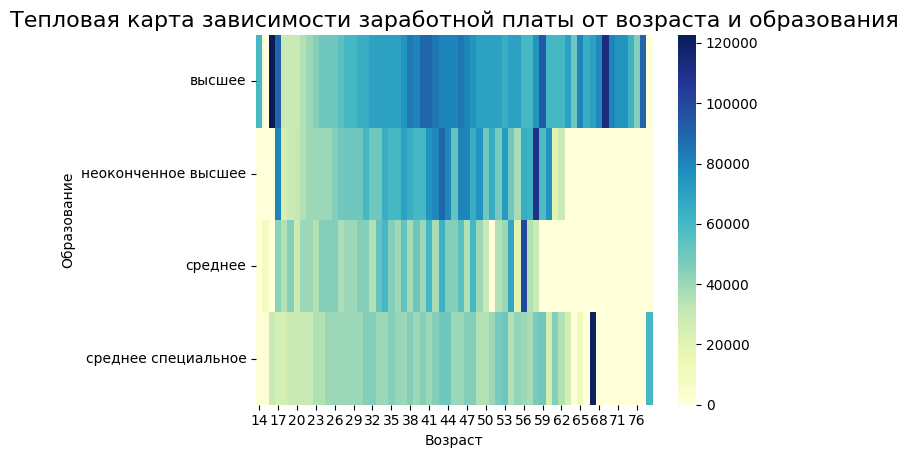

In [17]:
pivot = data.pivot_table(
    index='Образование',
    columns='Возраст',
    values='ЗП (руб)',
    aggfunc='median',
    fill_value=0
)
heatmap = sns.heatmap(data=pivot, cmap='YlGnBu')
heatmap.set_title('Тепловая карта зависимости заработной платы от возраста и образования', fontsize=16);

- Аномалии: например высшее образование до 17 лет.
- Очевидно, выская интенсивность увеличения ЗП у соискателей с высшим образования, а низкая интенсивность имеющие средние образование.

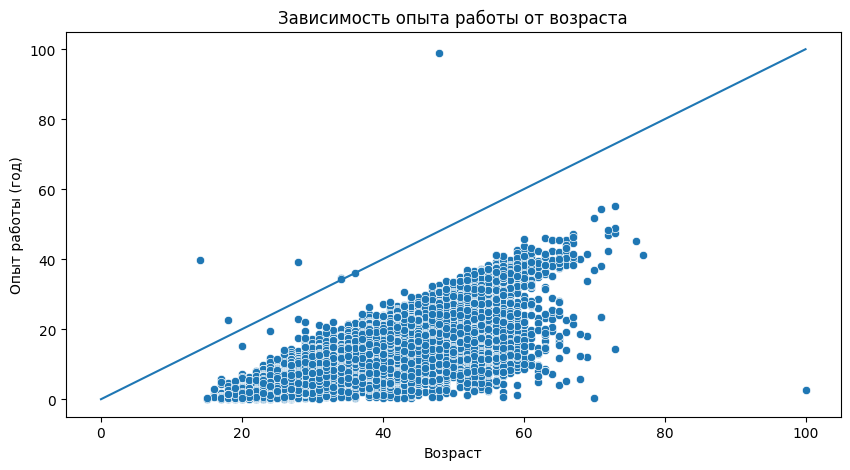

In [18]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig = plt.figure(figsize=(10, 5))
scatter_data = data.copy()
scatter_data['Опыт работы (год)'] = scatter_data['Опыт работы (месяц)']/12
sns.lineplot(x=[0, 100], y=[0, 100])
ax = sns.scatterplot(
    data=scatter_data, 
    x='Возраст',
    y='Опыт работы (год)',
)
ax.set_title('Зависимость опыта работы от возраста');

Наблюдается 5 выбросов

In [19]:
data_е = data[data['ЗП (руб)'] < 1e6]

fig = px.box(
    data_frame=data_е,
    x ='Готовность к переезду',
    y ='ЗП (руб)',
    color = 'Город',
    height=500,
    width=800,
    title = 'Распределение желаемой заработной платы в зависимости от города и готовности в переезду'
)

fig.show()

- Наиболее высокая желаемая ЗП при не готовности к переезду наблюдается в Москве
- Наиболее высокая желаемая ЗП при готовности к переезду наблюдается в других городах(возможно аномаьлный выброс)

In [20]:
bar_data = data.groupby(
    ['Готовность к командировкам', 'Пол'],
    as_index=False
)['ЗП (руб)'].median()
fig = px.bar(
    data_frame=bar_data,
    y='Пол',
    x='ЗП (руб)',
    barmode="group",
    color='Готовность к командировкам',
    orientation='h',
    title='Медианная з/п по готовности к командировкам'
)
fig.show()

- Среди мужского пола выше медианная желаемая ЗП 
- При готовности к переезду медианная желаемая ЗП выше

In [21]:
dupl_data = data.duplicated()
display(dupl_data.sum())

data_deduplicated = data.drop_duplicates()

np.int64(161)

In [22]:
data_copy = data_deduplicated.copy()
values = data_copy['Опыт работы (месяц)'].median()
data_copy ['Опыт работы (месяц)'] = data_copy ['Опыт работы (месяц)'].fillna(values)

display(data_copy['Опыт работы (месяц)'].isnull().sum())
data_copy = data_copy.dropna(axis=0)
display(round(data_copy['Опыт работы (месяц)'].mean()))
data_copy.shape[0]

np.int64(0)

114

44581

In [23]:
outliers = data[(data['ЗП (руб)'] > 1e6) | (data['ЗП (руб)'] < 1e3)]
data = data.drop(outliers.index)
print(outliers.shape[0])

89


In [24]:
outliers = data[data['Опыт работы (месяц)']/12 >= data['Возраст']]
data = data.drop(outliers.index)
print(outliers.shape[0])

7


Число выбросов по методу z-отклонения: 3


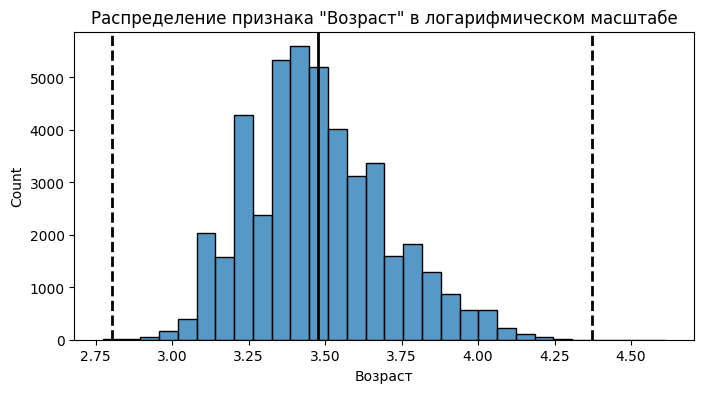

In [25]:
def outliers_z_score(data, feature, left=3, right=3, log_scale=False):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]

    mu = x.mean()
    sigma = x.std()

    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma

    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x > lower_bound) & (x < upper_bound)]

    return outliers, cleaned

outliers, cleaned = outliers_z_score(data, 'Возраст', 3, 4, log_scale=True)
print(f'Число выбросов по методу z-отклонения: {outliers.shape[0]}')

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_age = np.log(data['Возраст'] + 1)
histplot = sns.histplot(log_age, bins=30, ax=ax)
histplot.axvline(log_age.mean(), color='k', lw=2)
histplot.axvline(log_age.mean()+ 4 * log_age.std(), color='k', ls='--', lw=2)
histplot.axvline(log_age.mean()-3 * log_age.std(), color='k', ls='--', lw=2)
histplot.set_title('Распределение признака "Возраст" в логарифмическом масштабе');

Распределение имеет правую ассиметрию.